Выход Self-Attention:
 [[-0.32080902 -0.46976975 -0.19231589 -0.07677361]
 [-0.30249005 -0.57076556 -0.03681329  0.01880544]
 [-0.46126105 -0.36620523 -0.41823183  0.8562291 ]]

Матрица внимания (кто на кого смотрит):
 [[0.39285909 0.16818537 0.43895554]
 [0.23089671 0.28342933 0.48567396]
 [0.22547439 0.55874566 0.21577995]]


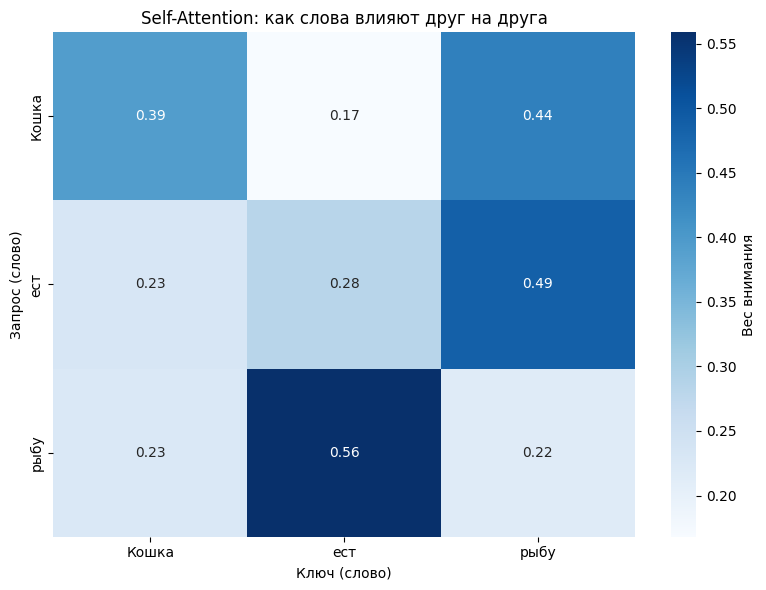

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def softmax(x, axis=-1):
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / np.sum(e_x, axis=axis, keepdims=True)

def self_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores, axis=-1)
    output = weights @ V
    return output, weights 

# Пример с 3 словами (векторы длины 4)
np.random.seed(42)
seq_len, d_k = 3, 4
Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_k)

output, attn_weights = self_attention(Q, K, V)
print("Выход Self-Attention:\n", output)
print("\nМатрица внимания (кто на кого смотрит):\n", attn_weights)


# Тепловая карта
def self_attention_with_vis(Q, K, V, words):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores, axis=-1)
    output = weights @ V
    plt.figure(figsize=(8, 6))
    sns.heatmap(weights, annot=True, fmt='.2f', 
                xticklabels=words, yticklabels=words,
                cmap='Blues', cbar_kws={'label': 'Вес внимания'})
    plt.title('Self-Attention: как слова влияют друг на друга')
    plt.ylabel('Запрос (слово)')
    plt.xlabel('Ключ (слово)')
    plt.tight_layout()
    plt.show()
    return output, weights
words = ['Кошка', 'ест', 'рыбу']
output, attn_weights = self_attention_with_vis(Q, K, V, words)

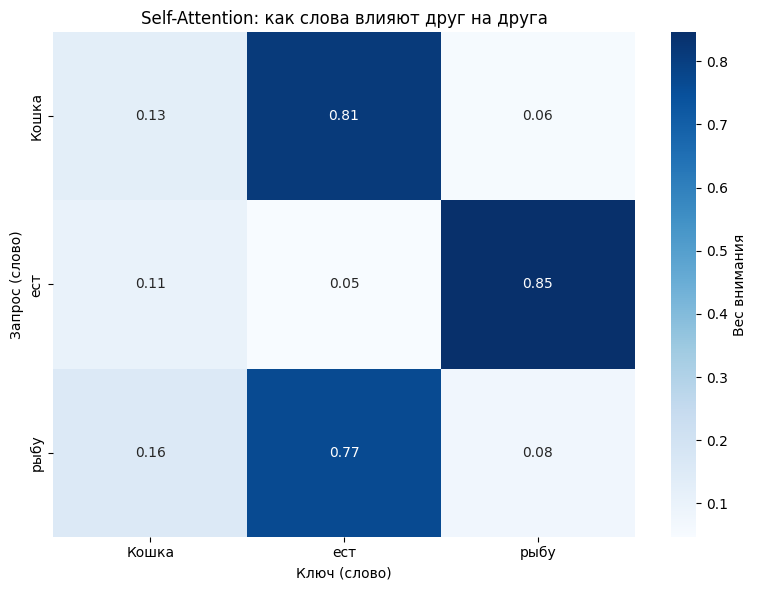


Интерпретация:
- 'Кошка' больше всего смотрит на 'ест' (кто совершает действие)
- 'ест' сильнее всего смотрит на 'рыбу' (что едят)
- 'рыбу' смотрит на 'ест' (кто действие совершает)


In [3]:
# Реальный пример: предложение из 3 слов

seq_len, d_k = 3, 4

# Создаём осмысленные эмбеддинги (для демонстрации)
np.random.seed(42)
Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_k)

# Подгоняем, чтобы "ест" сильнее смотрело на "рыбу" (упрощённо)
# В реальности это выучивается сетью
# 1. "Кошка" (индекс 0) должна смотреть на "ест" (индекс 1)
Q[0] = K[1] * 1.5   # запрос "Кошки" похож на ключ "ест"

# 2. "ест" (индекс 1) должна смотреть на "рыбу" (индекс 2)
Q[1] = K[2] * 1.5   # запрос "ест" похож на ключ "рыбу"

# 3. "рыбу" (индекс 2) может смотреть на "ест" (индекс 1)
Q[2] = K[1] * 1.3   # запрос "рыбу" похож на ключ "ест"

output, attn_weights = self_attention_with_vis(Q, K, V, words)
print("\nИнтерпретация:")
print("- 'Кошка' больше всего смотрит на 'ест' (кто совершает действие)")
print("- 'ест' сильнее всего смотрит на 'рыбу' (что едят)")
print("- 'рыбу' смотрит на 'ест' (кто действие совершает)")